# Analyse der Kundenabwanderung in der Kfz-Versicherung

# Datenimport

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

customer = pd.read_csv('/content/customer.csv')
demographic = pd.read_csv('/content/demographic.csv')
termination = pd.read_csv('/content/termination.csv')

# Datenverständnis

### Datensatzstruktur

In [75]:
customer.shape

(319966, 8)

In [76]:
demographic.shape

(504777, 9)

In [77]:
termination.shape

(269259, 2)

In [78]:
customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319966 entries, 0 to 319965
Data columns (total 8 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   INDIVIDUAL_ID           319966 non-null  float64
 1   ADDRESS_ID              319966 non-null  float64
 2   CURR_ANN_AMT            319966 non-null  float64
 3   DAYS_TENURE             319966 non-null  float64
 4   CUST_ORIG_DATE          319966 non-null  object 
 5   AGE_IN_YEARS            296464 non-null  float64
 6   DATE_OF_BIRTH           319965 non-null  object 
 7   SOCIAL_SECURITY_NUMBER  319965 non-null  object 
dtypes: float64(5), object(3)
memory usage: 19.5+ MB


In [79]:
demographic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504777 entries, 0 to 504776
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   INDIVIDUAL_ID        504777 non-null  float64
 1   INCOME               504777 non-null  float64
 2   HAS_CHILDREN         504777 non-null  float64
 3   LENGTH_OF_RESIDENCE  504777 non-null  float64
 4   MARITAL_STATUS       402007 non-null  object 
 5   HOME_MARKET_VALUE    459377 non-null  object 
 6   HOME_OWNER           504776 non-null  float64
 7   COLLEGE_DEGREE       504776 non-null  float64
 8   GOOD_CREDIT          504776 non-null  float64
dtypes: float64(7), object(2)
memory usage: 34.7+ MB


### Prüfung auf Duplikate



In [80]:
customer['INDIVIDUAL_ID'].nunique()

319966

In [81]:
demographic['INDIVIDUAL_ID'].nunique()

504777

In [82]:
termination['INDIVIDUAL_ID'].nunique()

269259

### Validierung der Datenverknüpfung

In [83]:
len(
    set(customer['INDIVIDUAL_ID'])
    &
    set(demographic['INDIVIDUAL_ID'])
)

70866

# Datenaufbereitung

In [84]:
master_df = customer.merge(
    demographic,
    on='INDIVIDUAL_ID',
    how='inner'
)

In [85]:
master_df.shape

(70866, 16)

In [86]:
master_df.head()

,INDIVIDUAL_ID,ADDRESS_ID,CURR_ANN_AMT,DAYS_TENURE,CUST_ORIG_DATE,AGE_IN_YEARS,DATE_OF_BIRTH,SOCIAL_SECURITY_NUMBER,INCOME,HAS_CHILDREN,LENGTH_OF_RESIDENCE,MARITAL_STATUS,HOME_MARKET_VALUE,HOME_OWNER,COLLEGE_DEGREE,GOOD_CREDIT
0,2.213000e+11,5.213000e+11,818.877997,1454.0,2018-12-09,44.474,1978-06-23,608-XX-7640,22500.0,1.0,15.0,Married,50000 - 74999,1.0,1.0,1.0
1,2.213007e+11,5.213002e+11,967.375112,4818.0,2009-09-23,55.444,1967-07-07,240-XX-9224,42500.0,0.0,10.0,Married,75000 - 99999,1.0,0.0,0.0
2,2.213027e+11,5.213010e+11,909.916163,484.0,2021-08-05,32.641,1990-04-20,194-XX-6050,52500.0,0.0,2.0,Married,125000 - 149999,1.0,0.0,1.0
3,2.213013e+11,5.213005e+11,905.038011,5336.0,2008-04-23,66.639,1956-04-29,188-XX-6698,125000.0,0.0,15.0,Married,125000 - 149999,1.0,1.0,1.0
4,2.213009e+11,5.213003e+11,961.044351,80.0,2022-09-13,55.444,1967-07-07,563-XX-7554,47500.0,0.0,0.0,NaN,NaN,0.0,0.0,1.0


In [87]:
termination['Churn'] = 1

In [88]:
master_df = master_df.merge(
    termination[['INDIVIDUAL_ID', 'Churn']],
    on='INDIVIDUAL_ID',
    how='left'
)

In [89]:
master_df['Churn'] = master_df['Churn'].fillna(0)

In [90]:
master_df['Churn'].value_counts()

,count
Churn,
0.0,62365
1.0,8501


In [91]:
master_df['Churn'].mean() * 100

np.float64(11.995879547314651)

# Feature Engineering

In [92]:
master_df['Age_Group'] = pd.cut(
    master_df['AGE_IN_YEARS'],
    bins=[0, 30, 40, 50, 60, np.inf],
    labels=['<30', '30-40', '40-50', '50-60', '60+'],
    right=False
)

In [93]:
master_df['Income_Group'] = pd.qcut(
    master_df['INCOME'],
    q=5,
    labels=[
        'Very Low',
        'Low',
        'Medium',
        'High',
        'Very High'
    ]
)

In [94]:
master_df['Tenure_Group'] = pd.cut(
    master_df['DAYS_TENURE'],
    bins=[0,730,1825,3650,10000],
    labels=[
        '0-2 Years',
        '2-5 Years',
        '5-10 Years',
        '10+ Years'
    ]
)

In [95]:
master_df = master_df.dropna(subset=['DAYS_TENURE'])

In [96]:
master_df['Tenure_Year'] = (
    master_df['DAYS_TENURE'] / 365
).astype(int)

In [97]:
master_df['Premium_Group'] = pd.qcut(
    master_df['CURR_ANN_AMT'],
    q=5,
    labels=[
        'Very Low',
        'Low',
        'Medium',
        'High',
        'Very High'
    ]
)

In [98]:
master_df['Residence_Group'] = pd.qcut(
    master_df['LENGTH_OF_RESIDENCE'],
    q=5,
    labels=[
        'Very Low',
        'Low',
        'Medium',
        'High',
        'Very High'
    ]
)

In [99]:
master_df.columns

Index(['INDIVIDUAL_ID', 'ADDRESS_ID', 'CURR_ANN_AMT', 'DAYS_TENURE',
       'CUST_ORIG_DATE', 'AGE_IN_YEARS', 'DATE_OF_BIRTH',
       'SOCIAL_SECURITY_NUMBER', 'INCOME', 'HAS_CHILDREN',
       'LENGTH_OF_RESIDENCE', 'MARITAL_STATUS', 'HOME_MARKET_VALUE',
       'HOME_OWNER', 'COLLEGE_DEGREE', 'GOOD_CREDIT', 'Churn', 'Age_Group',
       'Income_Group', 'Tenure_Group', 'Tenure_Year', 'Premium_Group',
       'Residence_Group'],
      dtype='object')

# Explorative Datenanalyse

## Alter


### Die Variable 'AGE_IN_YEARS' wird analysiert, um zu ermitteln, ob die Kündigungsrate in bestimmten Altersgruppen höher ist. Dazu wird die Variable in Altersklassen gruppiert und die entsprechenden prozentualen Anteile ausgegeben und visualisiert.

In [100]:
master_df.groupby('Churn')['AGE_IN_YEARS'].mean()

,AGE_IN_YEARS
Churn,
0.0,55.429794
1.0,53.218873


In [101]:
pd.crosstab(
    master_df['Age_Group'],
    master_df['Churn'],
    normalize='index'
) * 100

Churn,0.0,1.0
Age_Group,,
<30,83.080041,16.919959
30-40,86.267527,13.732473
40-50,87.712428,12.287572
50-60,86.936450,13.063550
60+,90.755361,9.244639


In [102]:
age_churn = (
    pd.crosstab(
        master_df['Age_Group'],
        master_df['Churn'],
        normalize='index'
    )[1.0]
    .mul(100)
    .round(2)
    .to_frame('Churn Rate (%)')
)

age_churn

,Churn Rate (%)
Age_Group,
<30,16.92
30-40,13.73
40-50,12.29
50-60,13.06
60+,9.24


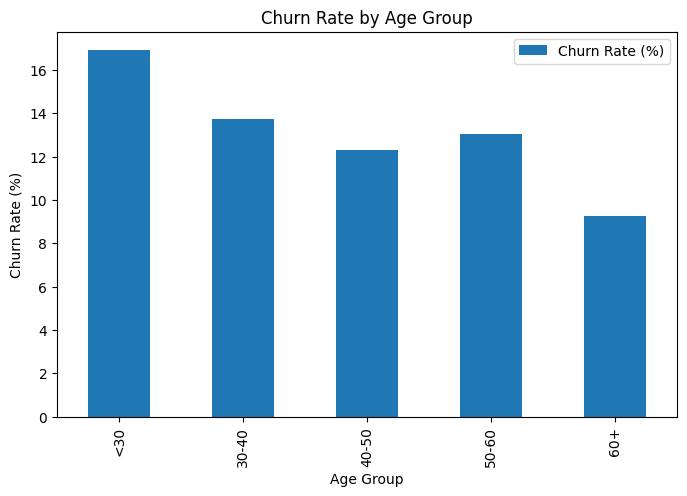

In [103]:
age_churn.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Churn Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate (%)')

plt.show()

###Die Kündigungsrate unterscheidet sich deutlich zwischen den Altersgruppen. Die höchste Kündigungsrate weisen Kunden unter 30 Jahren mit 16,92 % auf. Bei den 30–40-Jährigen liegt sie bei 13,73 % und bei den 40–50-Jährigen bei 12,29 %. In der Altersgruppe 50–60 steigt die Kündigungsrate leicht auf 13,06 %, während Kunden ab 60 Jahren mit 9,24 % die niedrigste Kündigungsrate aufweisen. Insgesamt weisen damit insbesondere jüngere Kunden ein erhöhtes Kündigungsrisiko auf.

## Einkommen

###Die Variable INCOME wird analysiert, um zu untersuchen, ob das Einkommen mit der Kündigungsrate in Zusammenhang steht. Dazu wird das Einkommen in fünf Gruppen unterteilt und die Kündigungsrate je Gruppe verglichen.

In [104]:
master_df.groupby('Churn')['INCOME'].mean()

,INCOME
Churn,
0.0,80446.198637
1.0,79203.447566


In [105]:
pd.crosstab(
    master_df['Income_Group'],
    master_df['Churn'],
    normalize='index'
) * 100

Churn,0.0,1.0
Income_Group,,
Very Low,87.576044,12.423956
Low,88.329009,11.670991
Medium,86.737508,13.262492
High,88.282591,11.717409
Very High,88.944424,11.055576


In [106]:
income_churn = (
    pd.crosstab(
        master_df['Income_Group'],
        master_df['Churn'],
        normalize='index'
    )[1.0]
    .mul(100)
    .round(2)
    .to_frame('Churn Rate (%)')
)

income_churn

,Churn Rate (%)
Income_Group,
Very Low,12.42
Low,11.67
Medium,13.26
High,11.72
Very High,11.06


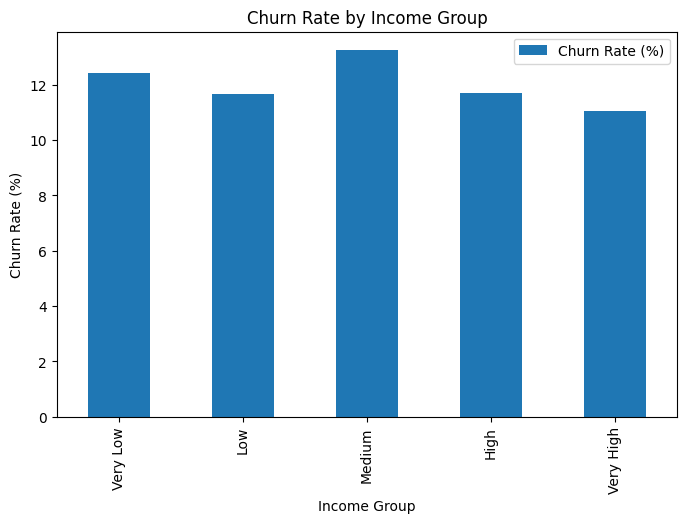

In [107]:
income_churn.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Churn Rate by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Churn Rate (%)')

plt.show()

### Die Kündigungsraten unterscheiden sich nur geringfügig zwischen den Einkommensgruppen. Die höchste Kündigungsrate weist die Gruppe „Medium“ mit 13,26 % auf, während die Gruppe „Very High“ mit 11,06 % die niedrigste Kündigungsrate aufweist. Insgesamt ist kein eindeutiges Muster erkennbar, nach dem die Kündigungsrate mit steigendem Einkommen systematisch zu- oder abnimmt. Das Einkommen zeigt daher in dieser Analyse nur einen geringen Zusammenhang mit der Kündigungsrate.

## Vertragsdauer

###Die Variable DAYS_TENURE wird analysiert, um zu untersuchen, ob die Vertragsdauer mit der Kündigungsrate in Zusammenhang steht. Dazu wird die Vertragsdauer in Gruppen unterteilt und die Kündigungsrate je Gruppe verglichen.

In [108]:
master_df.groupby('Churn')['DAYS_TENURE'].mean()

,DAYS_TENURE
Churn,
0.0,3578.485224
1.0,2055.435713


In [109]:
pd.crosstab(
    master_df['Tenure_Group'],
    master_df['Churn'],
    normalize='index'
) * 100

Churn,0.0,1.0
Tenure_Group,,
0-2 Years,65.479949,34.520051
2-5 Years,92.917290,7.082710
5-10 Years,92.930583,7.069417
10+ Years,92.892825,7.107175


In [110]:
tenure_churn = (
    pd.crosstab(
        master_df['Tenure_Group'],
        master_df['Churn'],
        normalize='index'
    )[1.0]
    .mul(100)
    .round(2)
    .to_frame('Churn Rate (%)')
)

tenure_churn

,Churn Rate (%)
Tenure_Group,
0-2 Years,34.52
2-5 Years,7.08
5-10 Years,7.07
10+ Years,7.11


In [111]:
tenure_year_churn = (
    pd.crosstab(
        master_df['Tenure_Year'],
        master_df['Churn'],
        normalize='index'
    )[1.0]
    .mul(100)
    .round(2)
    .to_frame('Churn Rate (%)')
)

tenure_year_churn

,Churn Rate (%)
Tenure_Year,
0,39.94
1,10.57
2,7.11
3,7.00
4,7.10
5,6.77
6,8.15
7,8.06
8,5.41


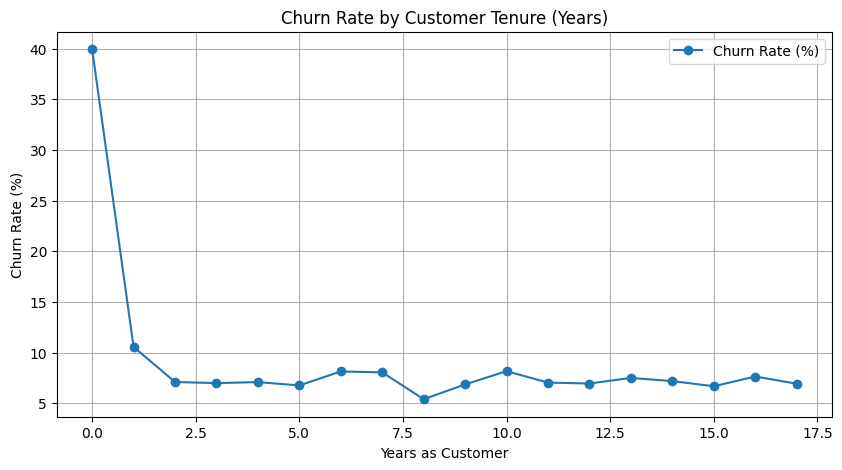

In [112]:
import matplotlib.pyplot as plt

tenure_year_churn.plot(
    kind='line',
    marker='o',
    figsize=(10,5)
)

plt.title('Churn Rate by Customer Tenure (Years)')
plt.xlabel('Years as Customer')
plt.ylabel('Churn Rate (%)')
plt.grid(True)

plt.show()

###Die Analyse zeigt, dass die Kündigungsrate im ersten Kundenjahr mit 39,94 % besonders hoch ist. Im zweiten Kundenjahr sinkt sie deutlich auf 10,57 %. Danach stabilisiert sich die Kündigungsrate überwiegend bei etwa 7 %. Die Ergebnisse zeigen damit, dass insbesondere die ersten beiden Vertragsjahre für die Kundenbindung relevant sind.

## Bonität

###Die Variable GOOD_CREDIT wird analysiert, um zu untersuchen, ob sich die Kündigungsrate zwischen Kunden mit und ohne gute Bonität unterscheidet. Dazu werden die Kündigungsraten beider Gruppen miteinander verglichen.

In [113]:
master_df['GOOD_CREDIT'].value_counts()

,count
GOOD_CREDIT,
1.0,57846
0.0,13020


In [114]:
credit_churn = (
    pd.crosstab(
        master_df['GOOD_CREDIT'],
        master_df['Churn'],
        normalize='index'
    )[1.0]
    .mul(100)
    .round(2)
    .to_frame('Churn Rate (%)')
)

credit_churn

,Churn Rate (%)
GOOD_CREDIT,
0.0,12.63
1.0,11.85


###Kunden ohne gute Bonität weisen eine Kündigungsrate von 12,63 % auf, Kunden mit guter Bonität eine Kündigungsrate von 11,85 %. Der Unterschied beträgt lediglich 0,78 Prozentpunkte und ist damit in dieser Analyse gering.

## Eigenheim

###Die Variable HOME_OWNER wird analysiert, um zu untersuchen, ob sich die Kündigungsrate zwischen Kunden mit und ohne Eigenheim unterscheidet. Dazu werden die Kündigungsraten beider Gruppen miteinander verglichen.

In [115]:
master_df['HOME_OWNER'].value_counts()

,count
HOME_OWNER,
1.0,49342
0.0,21524


In [116]:
homeowner_churn = (
    pd.crosstab(
        master_df['HOME_OWNER'],
        master_df['Churn'],
        normalize='index'
    )[1.0]
    .mul(100)
    .round(2)
    .to_frame('Churn Rate (%)')
)

homeowner_churn

,Churn Rate (%)
HOME_OWNER,
0.0,13.17
1.0,11.49


###Kunden ohne Eigenheim weisen eine Kündigungsrate von 13,17 % auf, während sie bei Eigenheimbesitzern bei 11,49 % liegt. Der Unterschied beträgt 1,68 Prozentpunkte. Damit zeigt sich ein moderater Zusammenhang zwischen Eigenheimbesitz und Kündigungsrate.

## Beziehungsstatus

###Die Variable MARITAL_STATUS wird analysiert, um zu untersuchen, ob sich die Kündigungsrate zwischen verheirateten und alleinstehenden Kunden unterscheidet. Dazu werden die Kündigungsraten beider Gruppen miteinander verglichen.

In [117]:
marital_churn = (
    pd.crosstab(
        master_df['MARITAL_STATUS'],
        master_df['Churn'],
        normalize='index'
    )[1.0]
    .mul(100)
    .round(2)
    .to_frame('Churn Rate (%)')
)

marital_churn

,Churn Rate (%)
MARITAL_STATUS,
Married,11.37
Single,12.06


###Verheiratete Kunden weisen eine Kündigungsrate von 11,37 % auf, während sie bei alleinstehenden Kunden bei 12,06 % liegt. Der Unterschied beträgt lediglich 0,69 Prozentpunkte und ist damit in dieser Analyse gering.

## Kinderstatus

###Die Variable HAS_CHILDREN wird analysiert, um zu untersuchen, ob sich die Kündigungsrate zwischen Kunden mit und ohne Kinder unterscheidet. Dazu werden die Kündigungsraten beider Gruppen miteinander verglichen.

In [118]:
children_churn = (
    pd.crosstab(
        master_df['HAS_CHILDREN'],
        master_df['Churn'],
        normalize='index'
    )[1.0]
    .mul(100)
    .round(2)
    .to_frame('Churn Rate (%)')
)

children_churn

,Churn Rate (%)
HAS_CHILDREN,
0.0,11.62
1.0,12.49


###Kunden ohne Kinder weisen eine Kündigungsrate von 11,62 % auf, während sie bei Kunden mit Kindern bei 12,49 % liegt. Der Unterschied beträgt 0,87 Prozentpunkte und ist damit in dieser Analyse gering.

## Aktuelle Jahresprämie

###Die Variable 'Curr_Ann_Amt' wird analysiert, um zu ermitteln, ob die Kündigungsrate höher ist gemessen an der aktuellen Jahresprämie. Dazu wird die Variable in 5 Gruppen unterteilt (Quintile, mittels pd.qcut()) und die entsprechenden prozentualen Anteile ausgegeben und visualisiert.

In [119]:
master_df['CURR_ANN_AMT'].describe().round(2)

,CURR_ANN_AMT
count,70866.00
mean,929.13
std,243.65
min,-31.05
25%,762.68
50%,923.94
75%,1090.09
max,2093.78


In [142]:
(master_df['CURR_ANN_AMT'] < 0).sum()

np.int64(2)

###Bei der Analyse von CURR_ANN_AMT wurden zwei negative Jahresprämien festgestellt. Dies entspricht lediglich etwa 0,003 % der analysierten Werte. Da negative Jahresprämien fachlich auffällig sind, werden diese als Datenqualitätsauffälligkeit dokumentiert. Aufgrund des sehr geringen Anteils werden die Werte für die weitere Analyse beibehalten.

In [121]:
premium_churn = (
    pd.crosstab(
        master_df['Premium_Group'],
        master_df['Churn'],
        normalize='index'
    )[1.0]
    .mul(100)
    .round(2)
    .to_frame('Churn Rate (%)')
)

premium_churn

,Churn Rate (%)
Premium_Group,
Very Low,10.89
Low,11.67
Medium,12.09
High,12.50
Very High,12.83


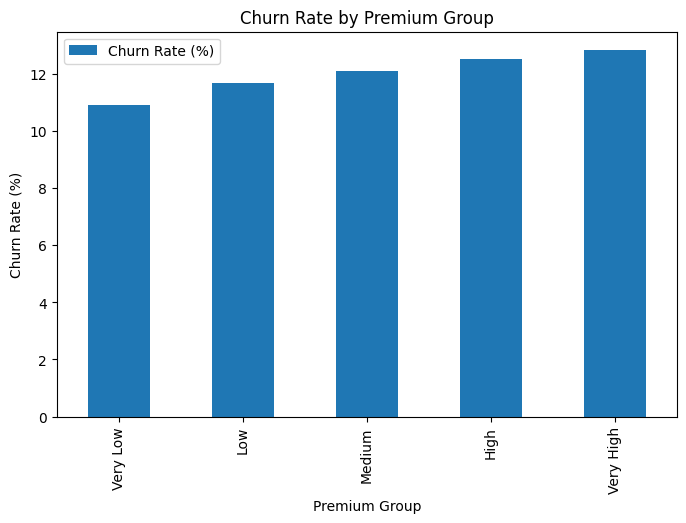

In [122]:
premium_churn.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Churn Rate by Premium Group')
plt.xlabel('Premium Group')
plt.ylabel('Churn Rate (%)')

plt.show()

###Die Kündigungsrate steigt mit zunehmender Jahresprämie von 10,89 % in der Gruppe „Very Low“ auf 12,83 % in der Gruppe „Very High“. Die Differenz zwischen der niedrigsten und höchsten Prämiengruppe beträgt 1,94 Prozentpunkte. Damit zeigt sich ein moderater Zusammenhang zwischen der Höhe der Jahresprämie und der Kündigungsrate.

## Wohndauer

###Die Variable LENGTH_OF_RESIDENCE wird analysiert, um zu untersuchen, ob die Wohndauer mit der Kündigungsrate in Zusammenhang steht. Dazu wird die Variable in fünf Gruppen unterteilt und die Kündigungsrate je Gruppe verglichen.

In [125]:
residence_churn = (
    pd.crosstab(
        master_df['Residence_Group'],
        master_df['Churn'],
        normalize='index'
    )[1.0]
    .mul(100)
    .round(2)
    .to_frame('Churn Rate (%)')
)

residence_churn

,Churn Rate (%)
Residence_Group,
Very Low,13.39
Low,12.41
Medium,12.45
High,11.14
Very High,9.91


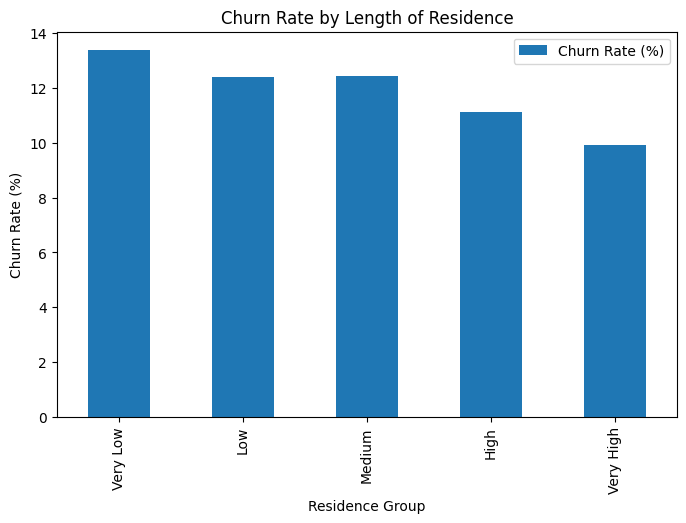

In [126]:
residence_churn.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Churn Rate by Length of Residence')
plt.xlabel('Residence Group')
plt.ylabel('Churn Rate (%)')

plt.show()

###Mit zunehmender Wohndauer sinkt die Kündigungsrate insgesamt von 13,39 % in der Gruppe „Very Low“ auf 9,91 % in der Gruppe „Very High“. Die Differenz beträgt 3,48 Prozentpunkte. Damit zeigt sich ein Zusammenhang zwischen längerer Wohndauer und einer niedrigeren Kündigungsrate.

##Wichtigste Ergebnisse der explorativen Datenanalyse

1.   Die Vertragsdauer zeigt den stärksten beobachteten Zusammenhang mit der Kündigungsrate.
2.   Jüngere Kunden weisen insgesamt höhere Kündigungsraten auf als ältere Kunden.
3. Eine längere Wohndauer steht mit niedrigeren Kündigungsraten in Zusammenhang.
4. Höhere Jahresprämien stehen mit leicht höheren Kündigungsraten in Zusammenhang.



##Variablen mit geringem Zusammenhang

1. Der Beziehungsstatus zeigt nur geringe Unterschiede bei den Kündigungsraten.
2. Der Eigenheimbesitz zeigt nur geringe Unterschiede bei den Kündigungsraten.
3. Die Bonität zeigt nur geringe Unterschiede bei den Kündigungsraten.
4. Der Kinderstatus zeigt nur geringe Unterschiede bei den Kündigungsraten.


#SQL Analyse

###Die SQL-Analyse dient der Segmentierung von Kunden und der Identifikation von Kundengruppen mit erhöhten Kündigungsraten.

In [127]:
conn = sqlite3.connect('insurance_churn.db')

In [128]:
master_df.to_sql(
    'customers',
    conn,
    if_exists='replace',
    index=False
)

70866

### Geschäftsfrage 1

###Welche Kombination aus Alter und Vertragsdauer weist die höchste Kündigungsrate auf?


In [133]:
query = """
SELECT
    Age_Group,
    Tenure_Group,
    COUNT(*) AS Kunden,
    ROUND(AVG(Churn) * 100, 2) AS Kuendigungsrate
FROM customers
GROUP BY
    Age_Group,
    Tenure_Group
ORDER BY
    Kuendigungsrate DESC;
"""

sql_age_tenure = pd.read_sql(query, conn)

sql_age_tenure

,Age_Group,Tenure_Group,Kunden,Kuendigungsrate
0,40-50,0-2 Years,2054,42.36
1,50-60,0-2 Years,4984,39.19
2,30-40,0-2 Years,2159,35.20
3,<30,0-2 Years,358,31.01
4,60+,0-2 Years,3113,21.81
5,<30,5-10 Years,349,10.03
6,<30,2-5 Years,275,7.64
7,50-60,5-10 Years,6198,7.57
8,50-60,2-5 Years,4369,7.37
9,50-60,10+ Years,12175,7.21


###Ergebnis

Die höchste Kündigungsrate weisen 40–50-jährige Kunden mit 0–2 Jahren Vertragsdauer auf (42,36 %). In allen Altersgruppen treten die höchsten Kündigungsraten innerhalb der ersten zwei Vertragsjahre auf.

### Geschäftsfrage 2

##Welche Kombination aus Alter und Jahresprämie weist die höchste Kündigungsrate auf?

In [134]:
query = """
SELECT
    Age_Group,
    Premium_Group,
    COUNT(*) AS Kunden,
    ROUND(AVG(Churn) * 100, 2) AS Kuendigungsrate
FROM customers
GROUP BY
    Age_Group,
    Premium_Group
ORDER BY
    Kuendigungsrate DESC;
"""

sql_age_premium = pd.read_sql(query, conn)

sql_age_premium

,Age_Group,Premium_Group,Kunden,Kuendigungsrate
0,<30,Low,213,18.78
1,<30,High,196,17.86
2,30-40,Very High,1393,17.80
3,<30,Medium,176,17.05
4,<30,Very Low,222,16.67
5,30-40,High,1646,15.07
6,50-60,Very High,5162,15.07
7,<30,Very High,180,13.89
8,50-60,High,5508,13.53
9,50-60,Medium,5642,13.31


### Ergebnis

Die höchste Kündigungsrate weisen Kunden unter 30 Jahren mit niedriger Jahresprämie auf (18,78 %). Ein eindeutiger Zusammenhang zwischen steigender Prämienhöhe und Kündigungsrate zeigt sich über die Altersgruppen hinweg nicht.

### Geschäftsfrage 3

Welche Kundensegmente weisen die geringste Kündigungswahrscheinlichkeit auf?

Diese Analyse identifiziert besonders stabile Kundengruppen und mögliche Merkmale langfristiger Kundenbindung.

In [136]:
query = """
SELECT
    Age_Group,
    Residence_Group,
    COUNT(*) AS Kunden,
    ROUND(AVG(Churn) * 100, 2) AS Kuendigungsrate
FROM customers
GROUP BY
    Age_Group,
    Residence_Group
ORDER BY
    Kuendigungsrate ASC;
"""

sql_stable_segments = pd.read_sql(query, conn)

sql_stable_segments

,Age_Group,Residence_Group,Kunden,Kuendigungsrate
0,60+,Very High,7126,8.10
1,60+,High,4083,9.14
2,<30,Very High,166,9.64
3,60+,Low,3023,9.99
4,60+,Medium,2400,10.29
5,60+,Very Low,3001,10.53
6,40-50,Very High,1138,10.54
7,40-50,High,2974,11.63
8,40-50,Medium,2447,11.69
9,50-60,High,4489,12.01


### Ergebnis

Die niedrigste Kündigungsrate weisen Kunden ab 60 Jahren mit sehr hoher Wohndauer auf (8,10 %). Insgesamt stehen höheres Alter und längere Wohndauer häufig mit niedrigeren Kündigungsraten in Zusammenhang.

### Geschäftsfrage 4

Welche zehn Kundensegmente weisen die höchsten Kündigungsraten auf?

Durch die Kombination mehrerer Kundenmerkmale werden die risikoreichsten Kundengruppen identifiziert. Ziel ist es, Segmente mit besonderem Retention-Potenzial zu erkennen.

In [137]:
query = """
SELECT
    Age_Group,
    Tenure_Group,
    Income_Group,
    Residence_Group,
    COUNT(*) AS Kunden,
    ROUND(AVG(Churn) * 100, 2) AS Kuendigungsrate
FROM customers
GROUP BY
    Age_Group,
    Tenure_Group,
    Income_Group,
    Residence_Group
HAVING COUNT(*) >= 100
ORDER BY
    Kuendigungsrate DESC
LIMIT 10;
"""

sql_top_risk = pd.read_sql(query, conn)

sql_top_risk

,Age_Group,Tenure_Group,Income_Group,Residence_Group,Kunden,Kuendigungsrate
0,40-50,0-2 Years,Very Low,Low,102,57.84
1,30-40,0-2 Years,High,Very Low,108,50.00
2,60+,0-2 Years,Very Low,Very Low,104,49.04
3,40-50,0-2 Years,Very High,Low,126,47.62
4,50-60,0-2 Years,High,Very Low,164,47.56
5,40-50,0-2 Years,Low,Very Low,146,47.26
6,50-60,0-2 Years,Very Low,Medium,119,44.54
7,40-50,0-2 Years,Low,Low,187,43.32
8,50-60,0-2 Years,Medium,Very Low,580,42.93
9,50-60,0-2 Years,Low,Very Low,387,42.38


###Ergebnis

Alle zehn Segmente mit den höchsten Kündigungsraten befinden sich in den ersten zwei Vertragsjahren. Die höchste Kündigungsrate erreicht das Segment 40–50 Jahre / sehr niedriges Einkommen / geringe Wohndauer mit 57,84 %.

# Externe Datenanalyse: Makroökonomische Einflussfaktoren

## Wie entwickelte sich die Inflation im wirtschaftlichen Umfeld bis zum Stichtag des Versicherungsdatensatzes?

In [138]:
url_inflation = "https://www.destatis.de/DE/Themen/Wirtschaft/Konjunkturindikatoren/Basisdaten/vpi001j.html"

inflation_raw = pd.read_html(
    url_inflation,
    decimal=",",
    thousands="."
)[0]

inflation_df = inflation_raw.iloc[:, :3].copy()

inflation_df.columns = [
    "Jahr",
    "Monat",
    "Inflationsrate"
]

inflation_df.head(10)

,Jahr,Monat,Inflationsrate
0,2026,Aug,2.9
1,2026,Jul,2.8
2,2026,Jun,2.3
3,2026,Mai,2.6
4,2026,Apr,2.9
5,2026,Mär,2.7
6,2026,Feb,1.9
7,2026,Jan,2.1
8,2025,Dez,1.8
9,2025,Nov,2.3


In [139]:
inflation_2021_2022 = inflation_df[
    (inflation_df['Jahr'] >= 2021) &
    (inflation_df['Jahr'] <= 2022)
].copy()

inflation_2021_2022.head(10)

,Jahr,Monat,Inflationsrate
44,2022,Dez,8.1
45,2022,Nov,8.8
46,2022,Okt,8.8
47,2022,Sep,8.6
48,2022,Aug,7.0
49,2022,Jul,6.7
50,2022,Jun,6.7
51,2022,Mai,7.0
52,2022,Apr,6.3
53,2022,Mär,5.9


In [140]:
month_map = {
    'Jan': 1, 'Feb': 2, 'Mär': 3, 'Apr': 4,
    'Mai': 5, 'Jun': 6, 'Jul': 7, 'Aug': 8,
    'Sep': 9, 'Okt': 10, 'Nov': 11, 'Dez': 12
}

inflation_2021_2022['Monat_Nr'] = inflation_2021_2022['Monat'].map(month_map)

inflation_2021_2022['Datum'] = pd.to_datetime(
    dict(
        year=inflation_2021_2022['Jahr'],
        month=inflation_2021_2022['Monat_Nr'],
        day=1
    )
)

inflation_2021_2022 = inflation_2021_2022.sort_values('Datum')

inflation_2021_2022.head()

,Jahr,Monat,Inflationsrate,Monat_Nr,Datum
67,2021,Jan,1.2,1,2021-01-01
66,2021,Feb,1.5,2,2021-02-01
65,2021,Mär,1.8,3,2021-03-01
64,2021,Apr,2.0,4,2021-04-01
63,2021,Mai,2.2,5,2021-05-01


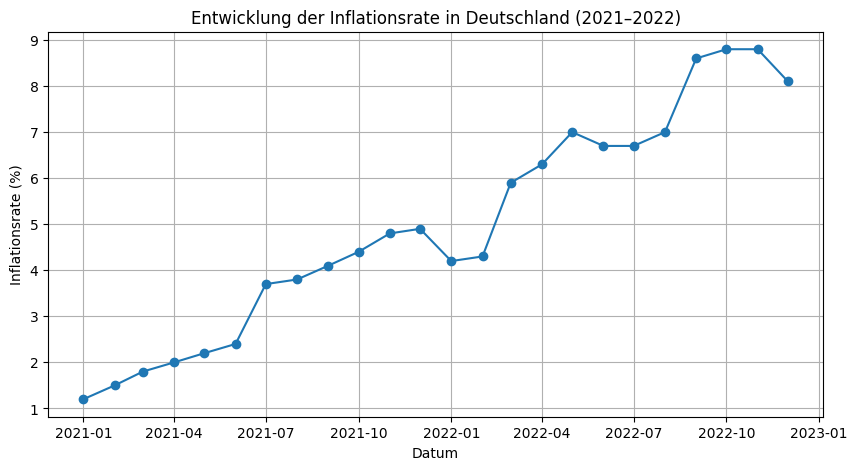

In [141]:
plt.figure(figsize=(10, 5))

plt.plot(
    inflation_2021_2022['Datum'],
    inflation_2021_2022['Inflationsrate'],
    marker='o'
)

plt.title('Entwicklung der Inflationsrate in Deutschland (2021–2022)')
plt.xlabel('Datum')
plt.ylabel('Inflationsrate (%)')
plt.grid(True)

plt.show()

### Ergebnis

Die Inflationsrate in Deutschland stieg von 1,2 % im Januar 2021 auf bis zu 8,8 % im Herbst 2022 deutlich an. Zum Stichtag des Versicherungsdatensatzes im Dezember 2022 lag die Inflationsrate bei 8,1 %.

Damit befanden sich die betrachteten Versicherungskunden zum Zeitpunkt der Datenerhebung in einem Umfeld stark gestiegener Verbraucherpreise. Dies deutet auf einen erhöhten allgemeinen Kostendruck für private Haushalte hin und kann die Preissensibilität gegenüber Versicherungsprämien erhöhen.

### Einschränkung

Der Versicherungsdatensatz enthält kein individuelles Kündigungsdatum. Daher kann kein direkter zeitlicher oder kausaler Zusammenhang zwischen Inflation und Kundenkündigungen nachgewiesen werden. Die Inflationsdaten dienen ausschließlich zur Einordnung des makroökonomischen Umfelds.

#Fazit und Handlungsempfehlungen

##Wichtigste Ergebnisse

- Vertragsdauer: Der stärkste beobachtete Zusammenhang besteht mit der Vertragsdauer. Im ersten Kundenjahr liegt die Kündigungsrate bei 39,94 %, im zweiten bei 10,57 % und danach überwiegend bei etwa 7 %.
- Alter: Kunden unter 30 Jahren weisen mit 16,92 % die höchste, Kunden ab 60 Jahren mit 9,24 % die niedrigste Kündigungsrate auf.
- Wohndauer: Längere Wohndauer steht insgesamt mit niedrigeren Kündigungsraten in Zusammenhang (13,39 % bis 9,91 %).
- Jahresprämie: Mit steigender Prämiengruppe erhöht sich die Kündigungsrate leicht von 10,89 % auf 12,83 %.
- SQL-Segmentierung: Alle zehn Segmente mit den höchsten Kündigungsraten befinden sich in den ersten zwei Vertragsjahren. Die höchste beobachtete Rate beträgt 57,84 %.
- Weitere Merkmale: Beziehungsstatus, Eigenheimbesitz, Bonität und Kinderstatus zeigen nur geringe Unterschiede.

##Handlungsempfehlung

Retention-Maßnahmen sollten sich insbesondere auf Kunden in den ersten beiden Vertragsjahren konzentrieren. Für eine gezieltere Priorisierung können zusätzlich Alter, Wohndauer und Jahresprämie berücksichtigt werden.